# Partie II — CNN sur Fashion-MNIST
**Module :** Deep Learning — EMSI Casablanca
**Étudiant(e) :** _(complète ton nom ici)_

Pipeline complet : théorie, description des données, EDA, calculs manuels, implémentations manuelles vs PyTorch, architecture CNN (LeNet), étude d'ablation, visualisation des feature maps, comparaison MLP vs CNN, entraînement, évaluation, synthèse.

## 1. Pourquoi un MLP est peu adapté aux images — idées fondatrices des CNN

- **Un MLP ignore la structure spatiale** : une image 28×28 est aplatie en un vecteur de 784 valeurs, détruisant les relations de voisinage entre pixels. Un MLP doit réapprendre depuis zéro qu'un pixel et son voisin sont liés.
- **Explosion du nombre de paramètres** : une première couche dense sur une image haute résolution nécessite un poids par pixel et par neurone — ne s'adapte pas à des images plus grandes.
- **Localité** : les CNN supposent qu'un motif visuel pertinent (un bord, une texture) est local — un filtre de petite taille (ex. 5×5) suffit à le détecter, peu importe sa position.
- **Partage des poids** : le même filtre est appliqué à toute l'image → invariance par translation et réduction drastique du nombre de paramètres comparé à une couche dense équivalente.
- **Hiérarchie des représentations** : les premières couches détectent des motifs simples (bords, textures), les couches profondes combinent ces motifs en concepts plus abstraits (formes, objets).

## 2. Imports et configuration

In [14]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import time

sns.set_style('whitegrid')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device utilisé :', device)

Device utilisé : cpu


## 3. Chargement et description des données — Fashion-MNIST

70 000 images en niveaux de gris (28×28), 10 classes de vêtements/accessoires. 60 000 pour l'entraînement, 10 000 pour le test. Plus difficile que MNIST (chiffres), plus léger que CIFAR-10 (couleur).

In [15]:
transform = transforms.ToTensor()
full_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)
classes = full_train.classes

print('Train:', len(full_train), '| Test:', len(test_ds))
print('Classes:', classes)

labels = full_train.targets.numpy()
unique, counts = np.unique(labels, return_counts=True)
for u,c in zip(unique, counts):
    print(f'  {classes[u]:15s}: {c}')

pixels = full_train.data.numpy().astype(np.float32)/255.0
print('\nPixels min/max/mean/std:', pixels.min(), pixels.max(), pixels.mean(), pixels.std())

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]


Train: 60000 | Test: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
  T-shirt/top    : 6000
  Trouser        : 6000
  Pullover       : 6000
  Dress          : 6000
  Coat           : 6000
  Sandal         : 6000
  Shirt          : 6000
  Sneaker        : 6000
  Bag            : 6000
  Ankle boot     : 6000

Pixels min/max/mean/std: 0.0 1.0 0.2860402 0.3530239


## 4. Exploration visuelle (EDA)

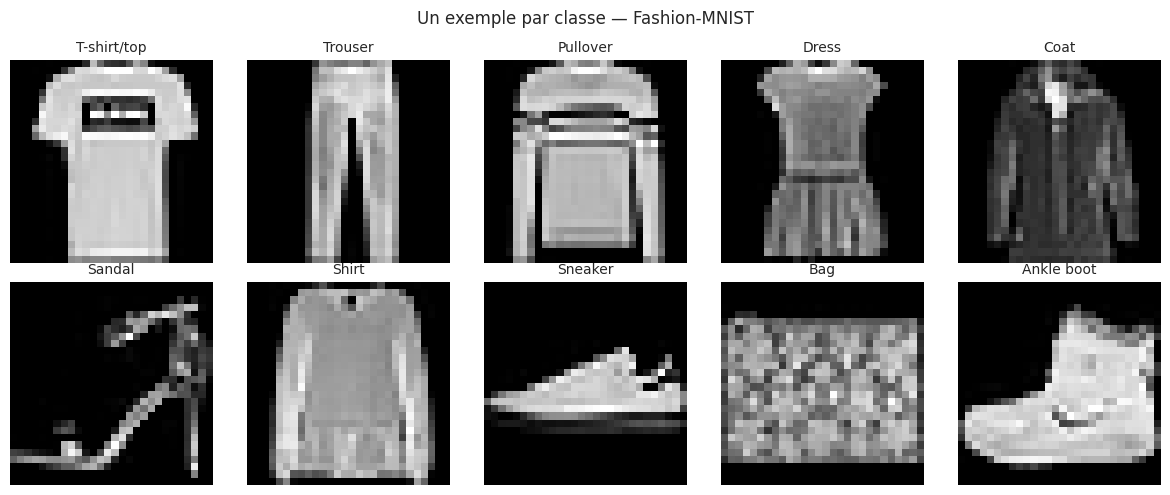

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    idx = np.where(labels==i)[0][0]
    img, _ = full_train[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[i], fontsize=10); ax.axis('off')
plt.suptitle('Un exemple par classe — Fashion-MNIST')
plt.tight_layout(); plt.show()

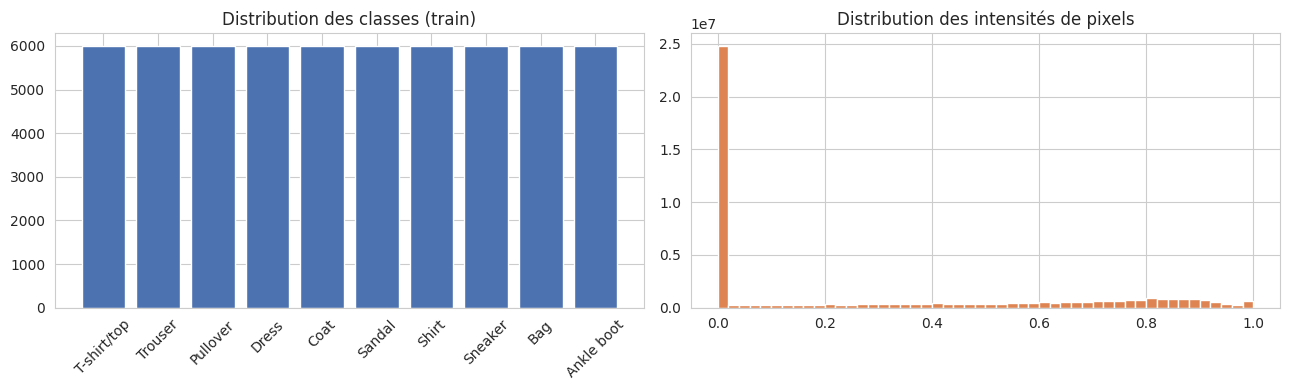

In [17]:
fig, axes = plt.subplots(1,2, figsize=(13,4))
axes[0].bar([classes[u] for u in unique], counts, color='#4C72B0')
axes[0].set_title('Distribution des classes (train)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].hist(pixels.flatten(), bins=50, color='#DD8452')
axes[1].set_title('Distribution des intensités de pixels')
plt.tight_layout(); plt.show()

**Observations :** dataset parfaitement équilibré (6000 images/classe). Beaucoup de pixels proches de 0 (fond noir), distribution bimodale typique d'images sur fond uniforme avec objet contrasté.

## 5. Calculs manuels — corrélation croisée, taille de sortie conv/pooling

**Formule générale (taille de sortie d'une convolution) :**

$$\text{out} = \left\lfloor \frac{H + 2P - K}{S} \right\rfloor + 1$$

avec $H$ = taille d'entrée, $P$ = padding, $K$ = taille du noyau, $S$ = stride. Même formule pour le pooling.

In [18]:
def conv_output_size(H, W, kh, kw, padding=0, stride=1):
    out_h = (H + 2*padding - kh)//stride + 1
    out_w = (W + 2*padding - kw)//stride + 1
    return out_h, out_w

print('Conv k=5, pad=0, stride=1, entrée 28x28 ->', conv_output_size(28,28,5,5,0,1))
print('Conv k=5, pad=2, stride=1, entrée 28x28 ->', conv_output_size(28,28,5,5,2,1))
print('Conv k=3, pad=1, stride=2, entrée 28x28 ->', conv_output_size(28,28,3,3,1,2))
print('Pooling 2x2, stride=2, entrée 24x24      ->', conv_output_size(24,24,2,2,0,2))

Conv k=5, pad=0, stride=1, entrée 28x28 -> (24, 24)
Conv k=5, pad=2, stride=1, entrée 28x28 -> (28, 28)
Conv k=3, pad=1, stride=2, entrée 28x28 -> (14, 14)
Pooling 2x2, stride=2, entrée 24x24      -> (12, 12)


## 6. Implémentations manuelles vs couches PyTorch

On programme la corrélation croisée 2D, le max-pooling et l'average-pooling "à la main", puis on vérifie qu'elles donnent EXACTEMENT le même résultat que `F.conv2d` / `nn.MaxPool2d` / `nn.AvgPool2d`.

In [20]:
def corr2d(X, K):
    """Corrélation croisée 2D, sans padding, stride=1."""
    h, w = K.shape
    H, W = X.shape
    out_h, out_w = H - h + 1, W - w + 1
    Y = torch.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

X = torch.tensor([[0.,1.,2.],[3.,4.,5.],[6.,7.,8.]])
K = torch.tensor([[0.,1.],[2.,3.]])
print('Corrélation croisée manuelle:\n', corr2d(X, K))

Y_torch = F.conv2d(X.view(1,1,3,3), K.view(1,1,2,2))
print('\nVia F.conv2d (PyTorch):\n', Y_torch.squeeze())
print('\n→ Identique : F.conv2d réalise en réalité une corrélation croisée, pas une vraie convolution mathématique (pas de retournement du noyau).')

Corrélation croisée manuelle:
 tensor([[19., 25.],
        [37., 43.]])

Via F.conv2d (PyTorch):
 tensor([[19., 25.],
        [37., 43.]])

→ Identique : F.conv2d réalise en réalité une corrélation croisée, pas une vraie convolution mathématique (pas de retournement du noyau).


In [21]:
def pool2d(X, pool_size, mode='max', stride=None):
    ph, pw = pool_size
    sh, sw = stride or pool_size
    H, W = X.shape
    out_h, out_w = (H-ph)//sh+1, (W-pw)//sw+1
    Y = torch.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            window = X[i*sh:i*sh+ph, j*sw:j*sw+pw]
            Y[i,j] = window.max() if mode=='max' else window.mean()
    return Y

Xp = torch.tensor([[1.,2.,3.,4.],[5.,6.,7.,8.],[9.,10.,11.,12.],[13.,14.,15.,16.]])
print('Max-pool manuel:\n', pool2d(Xp, (2,2), mode='max'))
print('Via nn.MaxPool2d:\n', nn.MaxPool2d(2)(Xp.view(1,1,4,4)).squeeze())
print('\nAvg-pool manuel:\n', pool2d(Xp, (2,2), mode='avg'))
print('Via nn.AvgPool2d:\n', nn.AvgPool2d(2)(Xp.view(1,1,4,4)).squeeze())

Max-pool manuel:
 tensor([[ 6.,  8.],
        [14., 16.]])
Via nn.MaxPool2d:
 tensor([[ 6.,  8.],
        [14., 16.]])

Avg-pool manuel:
 tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])
Via nn.AvgPool2d:
 tensor([[ 3.5000,  5.5000],
        [11.5000, 13.5000]])


## 7. Architecture CNN — inspirée de LeNet

Conv(1→6, k=5, pad=2) → ReLU → MaxPool(2) → Conv(6→16, k=5) → ReLU → MaxPool(2) → Flatten → FC(400→120) → ReLU → FC(120→84) → ReLU → FC(84→10)

In [22]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()

    def forward(self, x, return_features=False):
        f1 = self.relu(self.conv1(x))
        p1 = self.pool(f1)
        f2 = self.relu(self.conv2(p1))
        p2 = self.pool(f2)
        flat = p2.flatten(1)
        h1 = self.relu(self.fc1(flat))
        h2 = self.relu(self.fc2(h1))
        out = self.fc3(h2)
        if return_features:
            return out, f1, f2
        return out

model = LeNet()
for name, p in model.named_parameters():
    print(name, p.shape)
print('Nombre total de paramètres :', sum(p.numel() for p in model.parameters()))

conv1.weight torch.Size([6, 1, 5, 5])
conv1.bias torch.Size([6])
conv2.weight torch.Size([16, 6, 5, 5])
conv2.bias torch.Size([16])
fc1.weight torch.Size([120, 400])
fc1.bias torch.Size([120])
fc2.weight torch.Size([84, 120])
fc2.bias torch.Size([84])
fc3.weight torch.Size([10, 84])
fc3.bias torch.Size([10])
Nombre total de paramètres : 61706


## 8. Étude d'ablation — influence des choix architecturaux

On compare padding, stride, type de pooling, nombre de filtres, et présence d'une conv 1×1, sur un sous-ensemble (10000 train / 2000 val) pour aller vite (5 epochs chacun).

In [23]:
subset_idx = torch.randperm(len(full_train))[:12000]
sub_train = Subset(full_train, subset_idx[:10000])
sub_val = Subset(full_train, subset_idx[10000:])
train_loader_sub = DataLoader(sub_train, batch_size=128, shuffle=True)
val_loader_sub = DataLoader(sub_val, batch_size=256)

class FlexCNN(nn.Module):
    def __init__(self, padding=0, stride=1, pool_type='max', filters=(6,16), use_1x1=False):
        super().__init__()
        f1, f2 = filters
        layers1 = [nn.Conv2d(1, f1, kernel_size=5, padding=padding, stride=stride), nn.ReLU()]
        if use_1x1:
            layers1 += [nn.Conv2d(f1, f1, kernel_size=1), nn.ReLU()]
        self.block1 = nn.Sequential(*layers1)
        self.pool1 = nn.MaxPool2d(2) if pool_type=='max' else nn.AvgPool2d(2)
        self.block2 = nn.Sequential(nn.Conv2d(f1, f2, kernel_size=5, padding=padding, stride=stride), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2) if pool_type=='max' else nn.AvgPool2d(2)
        self.flatten = nn.Flatten()
        self.classifier = None

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.flatten(x)
        if self.classifier is None:
            self.classifier = nn.Sequential(nn.Linear(x.shape[1], 120), nn.ReLU(), nn.Linear(120, 10))
        return self.classifier(x)

def train_eval(model, n_epochs=5, lr=1e-3):
    xb0, _ = next(iter(train_loader_sub)); model(xb0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in train_loader_sub:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
    model.eval(); correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader_sub:
            pred = model(xb).argmax(1)
            correct += (pred==yb).sum().item(); total += yb.size(0)
    return correct/total

configs = [
    ('Baseline (pad=0, stride=1, max, 6/16)', dict(padding=0, stride=1, pool_type='max', filters=(6,16), use_1x1=False)),
    ('Avec padding=2',                        dict(padding=2, stride=1, pool_type='max', filters=(6,16), use_1x1=False)),
    ('Stride=2 (au lieu de pooling fort)',     dict(padding=2, stride=2, pool_type='max', filters=(6,16), use_1x1=False)),
    ('Average-pooling au lieu de max',        dict(padding=0, stride=1, pool_type='avg', filters=(6,16), use_1x1=False)),
    ('Plus de filtres (16/32)',               dict(padding=0, stride=1, pool_type='max', filters=(16,32), use_1x1=False)),
    ('Avec conv 1x1 après bloc1',             dict(padding=0, stride=1, pool_type='max', filters=(6,16), use_1x1=True)),
]

ablation_results = {}
for name, cfg in configs:
    torch.manual_seed(SEED)
    m = FlexCNN(**cfg)
    t0 = time.time()
    acc = train_eval(m)
    dt = time.time()-t0
    n_params = sum(p.numel() for p in m.parameters())
    ablation_results[name] = (acc, dt, n_params)
    print(f'{name:42s} | val_acc={acc:.4f} | temps={dt:.1f}s | params={n_params}')

Baseline (pad=0, stride=1, max, 6/16)      | val_acc=0.8025 | temps=19.5s | params=34622
Avec padding=2                             | val_acc=0.8310 | temps=24.9s | params=97982
Stride=2 (au lieu de pooling fort)         | val_acc=0.8045 | temps=12.1s | params=11582
Average-pooling au lieu de max             | val_acc=0.7885 | temps=20.4s | params=34622
Plus de filtres (16/32)                    | val_acc=0.8260 | temps=32.6s | params=76018
Avec conv 1x1 après bloc1                  | val_acc=0.7875 | temps=20.6s | params=34664


**Interprétation attendue :**
- **Padding=2** préserve la résolution spatiale plus longtemps dans le réseau → généralement améliore l'accuracy.
- **Stride=2** réduit la résolution plus agressivement (comme un pooling intégré à la conv) → moins de paramètres, souvent un peu moins précis qu'un pooling séparé bien réglé.
- **Average-pooling** lisse l'information (moins de pic de signal) → souvent légèrement moins discriminant que **max-pooling**, qui conserve l'activation la plus forte (utile pour détecter la présence d'un motif).
- **Plus de filtres** augmente la capacité du modèle → meilleure accuracy mais plus de paramètres et de temps de calcul.
- **Conv 1×1** sert surtout à mélanger l'information entre canaux à coût quasi nul en paramètres spatiaux (utile dans des architectures profondes type Inception/ResNet) ; sur un réseau aussi petit que LeNet, son effet est marginal voire défavorable.

Compare avec TES propres valeurs obtenues.

## 9. Visualisation des feature maps

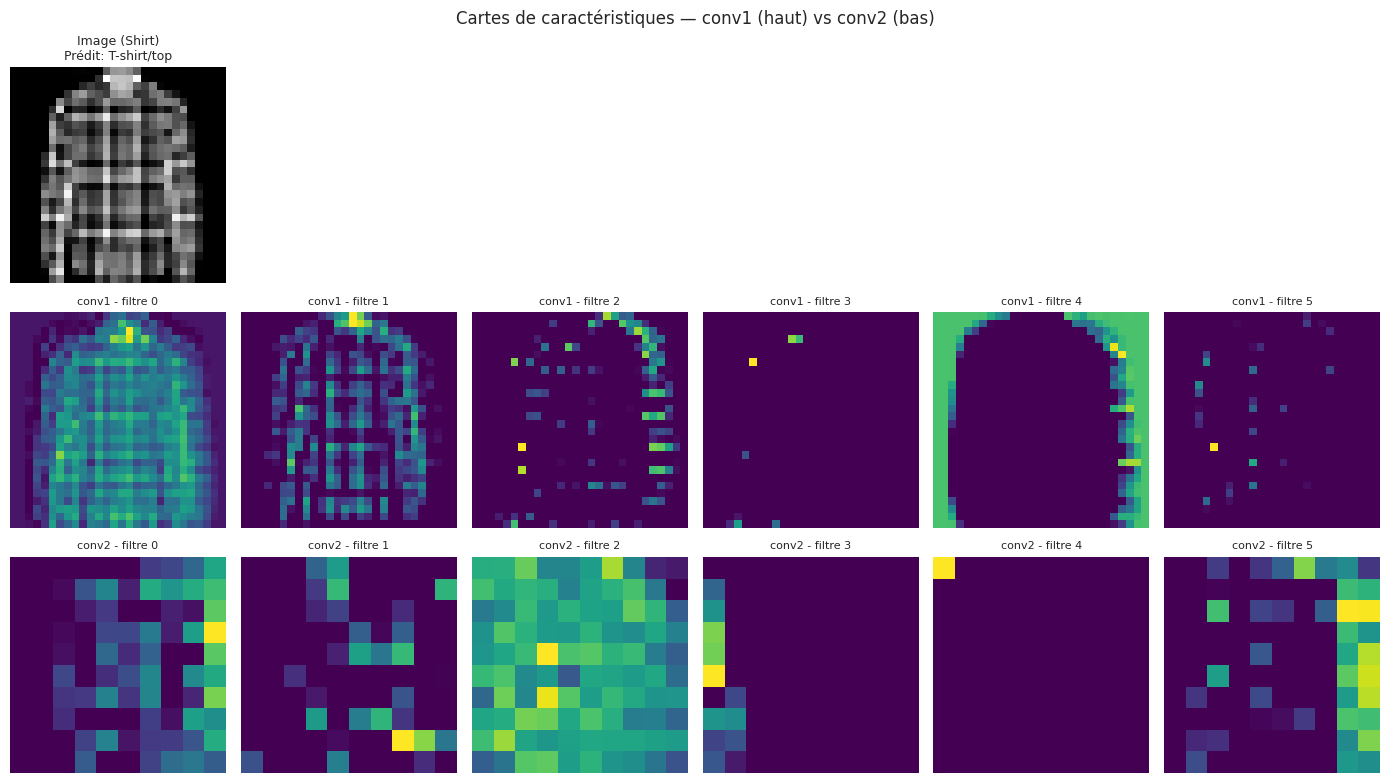

In [24]:
img, label = test_ds[7]
model.eval()
with torch.no_grad():
    out, f1, f2 = model(img.unsqueeze(0), return_features=True)
pred = out.argmax(1).item()

fig, axes = plt.subplots(3, 6, figsize=(14,8))
axes[0,0].imshow(img.squeeze(), cmap='gray')
axes[0,0].set_title(f'Image ({classes[label]})\nPrédit: {classes[pred]}', fontsize=9); axes[0,0].axis('off')
for i in range(1,6): axes[0,i].axis('off')
for i in range(6):
    axes[1,i].imshow(f1[0,i].numpy(), cmap='viridis'); axes[1,i].set_title(f'conv1 - filtre {i}', fontsize=8); axes[1,i].axis('off')
for i in range(6):
    axes[2,i].imshow(f2[0,i].numpy(), cmap='viridis'); axes[2,i].set_title(f'conv2 - filtre {i}', fontsize=8); axes[2,i].axis('off')
plt.suptitle('Cartes de caractéristiques — conv1 (haut) vs conv2 (bas)')
plt.tight_layout(); plt.show()

**Interprétation :** les filtres de `conv1` détectent des motifs simples (contours, transitions clair/sombre). Les filtres de `conv2`, appliqués après un premier pooling, combinent ces motifs en représentations plus abstraites et plus compactes spatialement — illustration directe de la hiérarchie des représentations.

## 10. Comparaison MLP vs CNN (même dataset, même nombre d'epochs)

In [25]:
n_train = 50000
train_ds, val_ds = random_split(full_train, [n_train, len(full_train)-n_train],
                                  generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)
test_loader = DataLoader(test_ds, batch_size=512)

class MLPbaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

def train_model(model, n_epochs, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss':[], 'val_acc':[]}
    for epoch in range(n_epochs):
        model.train(); epoch_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            epoch_loss += loss.item()*xb.size(0)
        epoch_loss /= len(train_ds)
        model.eval(); correct, total = 0,0
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb).argmax(1)
                correct += (pred==yb).sum().item(); total += yb.size(0)
        val_acc = correct/total
        history['train_loss'].append(epoch_loss); history['val_acc'].append(val_acc)
        print(f'  epoch {epoch+1}: train_loss={epoch_loss:.4f}  val_acc={val_acc:.4f}')
    return history

def test_eval(model):
    model.eval(); correct, total = 0,0; all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb).argmax(1)
            correct += (pred==yb).sum().item(); total += yb.size(0)
            all_preds.append(pred); all_true.append(yb)
    return correct/total, torch.cat(all_preds), torch.cat(all_true)

print('=== MLP baseline ===')
mlp = MLPbaseline()
hist_mlp = train_model(mlp, n_epochs=8)
acc_mlp, preds_mlp, true_mlp = test_eval(mlp)
n_params_mlp = sum(p.numel() for p in mlp.parameters())
print(f'Test accuracy MLP: {acc_mlp:.4f} | params: {n_params_mlp}')

print('\n=== CNN (LeNet) ===')
cnn = LeNet()
hist_cnn = train_model(cnn, n_epochs=8)
acc_cnn, preds_cnn, true_cnn = test_eval(cnn)
n_params_cnn = sum(p.numel() for p in cnn.parameters())
print(f'Test accuracy CNN: {acc_cnn:.4f} | params: {n_params_cnn}')

torch.save(cnn.state_dict(), 'best_cnn.pt')

=== MLP baseline ===
  epoch 1: train_loss=0.6756  val_acc=0.8385
  epoch 2: train_loss=0.4308  val_acc=0.8519
  epoch 3: train_loss=0.3849  val_acc=0.8649
  epoch 4: train_loss=0.3572  val_acc=0.8657
  epoch 5: train_loss=0.3353  val_acc=0.8766
  epoch 6: train_loss=0.3146  val_acc=0.8761
  epoch 7: train_loss=0.3034  val_acc=0.8793
  epoch 8: train_loss=0.2884  val_acc=0.8794
Test accuracy MLP: 0.8697 | params: 235146

=== CNN (LeNet) ===
  epoch 1: train_loss=0.9241  val_acc=0.7635
  epoch 2: train_loss=0.5398  val_acc=0.8128
  epoch 3: train_loss=0.4611  val_acc=0.8230
  epoch 4: train_loss=0.4152  val_acc=0.8547
  epoch 5: train_loss=0.3797  val_acc=0.8586
  epoch 6: train_loss=0.3538  val_acc=0.8688
  epoch 7: train_loss=0.3383  val_acc=0.8702
  epoch 8: train_loss=0.3207  val_acc=0.8584
Test accuracy CNN: 0.8539 | params: 61706


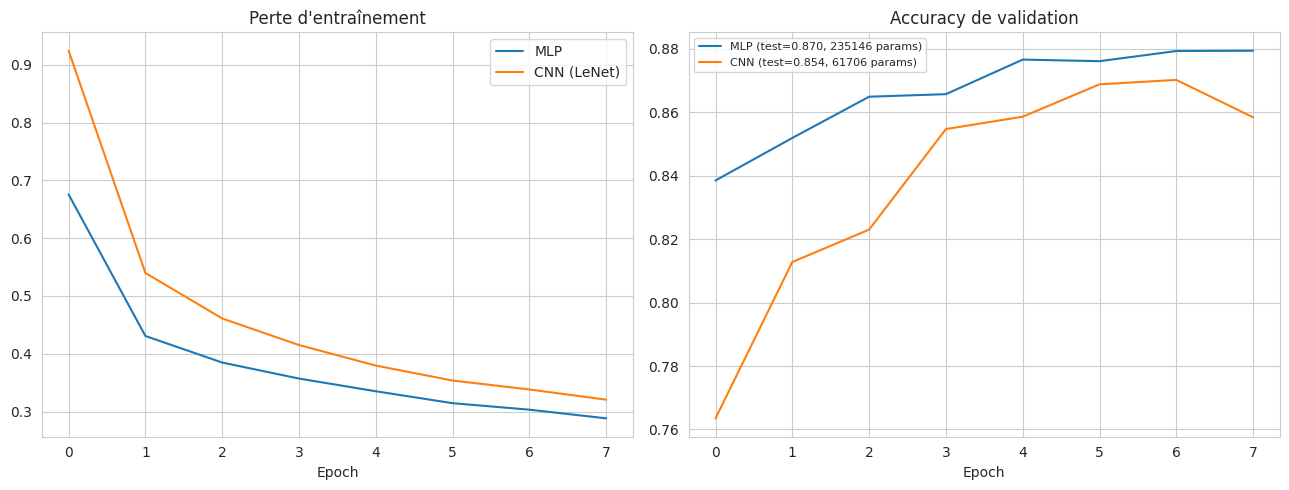

In [26]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].plot(hist_mlp['train_loss'], label='MLP')
axes[0].plot(hist_cnn['train_loss'], label='CNN (LeNet)')
axes[0].set_title("Perte d'entraînement"); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(hist_mlp['val_acc'], label=f'MLP (test={acc_mlp:.3f}, {n_params_mlp} params)')
axes[1].plot(hist_cnn['val_acc'], label=f'CNN (test={acc_cnn:.3f}, {n_params_cnn} params)')
axes[1].set_title('Accuracy de validation'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Point clé pour l'analyse critique :** le CNN atteint une accuracy comparable (voire supérieure) au MLP avec **nettement moins de paramètres** (grâce au partage des poids), illustrant le bon biais inductif des CNN pour les images. À nombre d'epochs égal, le CNN peut être plus lent par epoch (plus d'opérations de convolution), mais converge souvent vers une meilleure généralisation avec plus d'entraînement.

## 11. Évaluation finale du CNN (matrice de confusion)

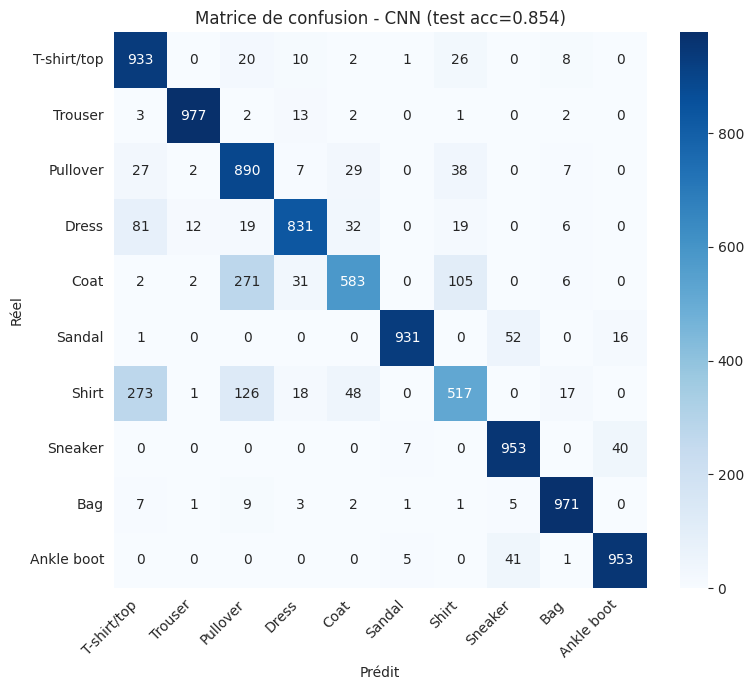

In [27]:
cm = confusion_matrix(true_cnn.numpy(), preds_cnn.numpy())
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Matrice de confusion - CNN (test acc={acc_cnn:.3f})')
plt.xlabel('Prédit'); plt.ylabel('Réel'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()